In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# Imports
import torch
import pandas as pd
import os 
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import chisquare

from vae import GroupHardMax
from finetuner import get_matching_indices


In [54]:
# Functions

def rmse(arr1, arr2):
    return np.sqrt(((arr1 - arr2)**2).sum()/len(arr1))

def kl(arr1, arr2):
    return np.sum(arr1*np.log(arr1/arr2))
def plot_vars_bars(marginals, predicted_marginals, state_marginals, variables, legend=False, figsize= (10,5), bbox_to_anchor = (1,1), img_name = None):
    num_keys_per_variable = []
    num_keys = 0
    for v in variables:
        # Count how many keys match v
        keys_v = [k for k in predicted_marginals.keys() if k.startswith(v)]
        num_keys_per_variable.append(len(keys_v))
        num_keys += len(keys_v)

    fig = plt.figure(figsize=figsize)  # Overall size; adjust as needed

    # Create a 1-row, len(variables)-column grid,
    # with column widths proportional to the number of categories
    gs = GridSpec(1, len(variables), width_ratios=num_keys_per_variable, wspace=0.2)

    axes = []
    for i in range(len(variables)):
        if i == 0:
            ax = fig.add_subplot(gs[i])  # first subplot
        else:
            ax = fig.add_subplot(gs[i])
            ax.sharey(axes[0])          # share y-axis with first subplot
        axes.append(ax)

    for i, v in enumerate(variables):
        ax = axes[i]
        
        # Get keys & data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals[k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = [m/sum(pred_marginals_v) for m in pred_marginals_v]
        gt_marginals_v = [m/sum(gt_marginals_v) for m in gt_marginals_v]
        state_marginals_v = [m/sum(state_marginals_v) for m in state_marginals_v]

        # Calculate chi square p value
        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_sub = pred_marginals_v[:-1]
            gt_marginals_sub = gt_marginals_v[:-1]
            state_marginals_sub = state_marginals_v[:-1]

            pred_marginals_sub = [m/sum(pred_marginals_sub) for m in pred_marginals_sub]
            gt_marginals_sub = [m/sum(gt_marginals_sub) for m in gt_marginals_sub]
            state_marginals_sub = [m/sum(state_marginals_sub) for m in state_marginals_sub]

            _, p_tract = chisquare(pred_marginals_sub, gt_marginals_sub)
            _, p_state = chisquare(state_marginals_sub, gt_marginals_sub)
        else:
            _, p_tract = chisquare(pred_marginals_v, gt_marginals_v)
            _, p_state = chisquare(state_marginals_v, gt_marginals_v)

        # Positions for bars
        x = np.arange(len(keys))
        width = 0.2

        # Plot grouped bars
        axes[i].bar(x,                 state_marginals_v, width=width, label='State Marginals')
        axes[i].bar(x + width,         pred_marginals_v,  width=width, label='Synthetic Marginals')
        axes[i].bar(x + 2 * width,     gt_marginals_v,    width=width, label='Groundtruth Marginals')

        # Plot p value
        if v == 'HHL':
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f} (Excluding Other)\nP_s = {p_state:.2f} (Excluding Other)', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')
        else:
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f}\nP_s = {p_state:.2f}', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')

        # Nicely align ticks
        axes[i].set_xticks(x + width)
        axes[i].set_xticklabels([k.removeprefix(v + ':') for k in keys], rotation=90)

        # Give the bars a bit of left-right padding
        axes[i].set_xlim([-0.5, len(keys)])

        axes[i].set_title(variables_dict[v])

    if legend:
        fig.legend(*axes[0].get_legend_handles_labels(),
            loc='upper right', bbox_to_anchor=bbox_to_anchor)

    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}')
    plt.show()

def get_marginals(data_table, household_indices, personal_indices, nan_indices):
    n_households = data_table.shape[0]

    marginals = {}
    # Handle household variables
    for var, indices in household_indices.items():
        marginals[var] = data_table[:, indices].mean()

    # Handle personal variables
    n_people_per_household = len(list(personal_indices.values())[0])
    n_people_with_nans = n_people_per_household * n_households

    for var, indices in personal_indices.items():
        matching_nan_variable = var.split(":")[0] + ':' + 'nan' # Eg for SEX:male, matching nan variable is SEX:nan
        n_people = n_people_with_nans - data_table[:, nan_indices[matching_nan_variable]].sum()
        marginals[var] = data_table[:, indices].sum()/n_people

    return marginals

def create_table(marginals, predicted_marginals, state_marginals, file_name):
    RMSEs_baseline = {}
    RMSEs_synth = {}
    KLs_baseline = {}
    KLs_synth = {}

    variables = ['TEN', 'VEH', 'HHL', 'HINCP', 'R18', 'R65', 'AGEP', 'SCHL', 'SEX']
    for v in variables:
        # Get data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals    [k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = np.array([m/sum(pred_marginals_v) for m in pred_marginals_v])
        gt_marginals_v = np.array([m/sum(gt_marginals_v) for m in gt_marginals_v])
        state_marginals_v = np.array([m/sum(state_marginals_v) for m in state_marginals_v])

        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_v = pred_marginals_v[:-1]
            gt_marginals_v = gt_marginals_v[:-1]
            state_marginals_v = state_marginals_v[:-1]

            pred_marginals_v /= pred_marginals_v.sum()
            gt_marginals_v /= gt_marginals_v.sum()
            state_marginals_v /= state_marginals_v.sum()

        RMSEs_baseline[v] = rmse(state_marginals_v, gt_marginals_v)
        RMSEs_synth[v] = rmse(pred_marginals_v, gt_marginals_v)
        KLs_baseline[v] = kl(state_marginals_v, gt_marginals_v)
        KLs_synth[v] = kl(pred_marginals_v, gt_marginals_v)

    table = pd.DataFrame([RMSEs_baseline, RMSEs_synth, KLs_baseline, KLs_synth], index = ['RMSE Baseline', 'RMSE Syn. HI.', 'KL Baseline', 'KL Syn. HI.'])
    table.to_csv(f'/workspace/finetune_pngs_dfs/{file_name}.csv')
    return table


In [55]:
# Useful variables

group_sizes = [
    2,    5,    5,    11,    2,    2,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,]

variables_dict = {
    'TEN': 'Tenure',
    'HHL': 'Household Language',
    'VEH': 'Vehicles avaiable',
    'HINCP': 'Household Income (Thousands of USD)',
    'AGEP': 'Age (in years)',
    'SEX': 'Sex',
    'R65': 'Persons 65 years ≤',
    'R18': 'Persons ≤18 years',
    'SCHL': 'Education',
}

# Data Handling

In [56]:
# Read state data
# Get pums_data and marginals
data_name = "one_hot_pNaNs_agep_21.csv"
pums_data = pd.read_csv(f"/workspace/data/{data_name}")
pums_np = pums_data.to_numpy()

# Read marginals
with open("/workspace/data/ACS_tract_tables/Delaware50101/marginals.json") as f:
    marginals = json.load(f)

# Read predictions data and make one-hot
prediction_folder = '/workspace/finetuned_models/predictions/' # Get path

prediction_paths = os.listdir(prediction_folder)
prediction_path = prediction_folder + prediction_paths[0]

predictions_torch = torch.load(prediction_path) # Load
predictions_unchanged = predictions_torch.detach().cpu().numpy()


hardmax = GroupHardMax(group_sizes) # Make one-hot
predictions_onehot = hardmax(predictions_torch)
synth_data = predictions_onehot.detach().cpu().numpy()

# Get marginals for predicted, predicted_cheating and state data
household_indices, personal_indices, nan_indices = get_matching_indices(marginals, list(pums_data.columns))

# Get marginal values for the predictions:
predicted_marginals         = get_marginals(synth_data, household_indices, personal_indices, nan_indices)
predicted_marginals_cheat   = get_marginals(predictions_unchanged, household_indices, personal_indices, nan_indices)
state_marginals             = get_marginals(pums_np, household_indices, personal_indices, nan_indices)

# Create dir for results
os.makedirs('/workspace/finetune_pngs_dfs', exist_ok = True)

In [57]:


# prepare dicts and namings for plotting
labels = list(pums_data.columns)
labels = [label.split(":") for label in labels]
feature_label_dict = {}
for key, label in labels:
    if key in feature_label_dict:
        feature_label_dict[key].append(label) 
    else:
        feature_label_dict[key] = [label]

indices = {}

for key, label in labels:
    if key in indices:
        indices[key].append(pums_data.columns.get_loc(f"{key}:{label}"))
    else:
        indices[key] = [pums_data.columns.get_loc(f"{key}:{label}")]

ten_dict = {key: [] for key in feature_label_dict['TEN']}
hhl_dict = {key: [] for key in feature_label_dict['HHL']}
veh_dict = {key: [] for key in feature_label_dict['VEH']}
hincp_dict = {key: [] for key in feature_label_dict['HINCP']}
sex_dict = {key: [] for key in feature_label_dict['SEX_1']}
education_dict = {key: [] for key in feature_label_dict['SCHL_1']}
age_dict = {key: [] for key in feature_label_dict['AGEP_1']}
r18_dict = {key: [] for key in feature_label_dict['R18']}
r65_dict = {key: [] for key in feature_label_dict['R65']}

# create dicts for the groups and their indices 
for key, labels in feature_label_dict.items():
    if 'SEX' in key:
        for idx, label in enumerate(labels):
            sex_dict[label].append(indices[key][idx])
    elif 'SCHL' in key:
        for idx, label in enumerate(labels):
            education_dict[label].append(indices[key][idx])
    elif 'AGEP' in key:
        for idx, label in enumerate(labels):
            age_dict[label].append(indices[key][idx])
    elif 'TEN' in key:
        for idx, label in enumerate(labels):
            ten_dict[label].append(indices[key][idx])
    elif 'HHL' in key:
        for idx, label in enumerate(labels):
            hhl_dict[label].append(indices[key][idx])
    elif 'VEH' in key:
        for idx, label in enumerate(labels):
            veh_dict[label].append(indices[key][idx])
    elif 'HINCP' in key:
        for idx, label in enumerate(labels):
            hincp_dict[label].append(indices[key][idx])
    elif 'R18' in key:
        for idx, label in enumerate(labels):
            r18_dict[label].append(indices[key][idx])
    elif 'R65' in key:
        for idx, label in enumerate(labels):
            r65_dict[label].append(indices[key][idx])


households = [ten_dict, hhl_dict, veh_dict, hincp_dict, r18_dict, r65_dict]
individuals = [sex_dict, education_dict, age_dict]


# Recreate Figure 10, table 4

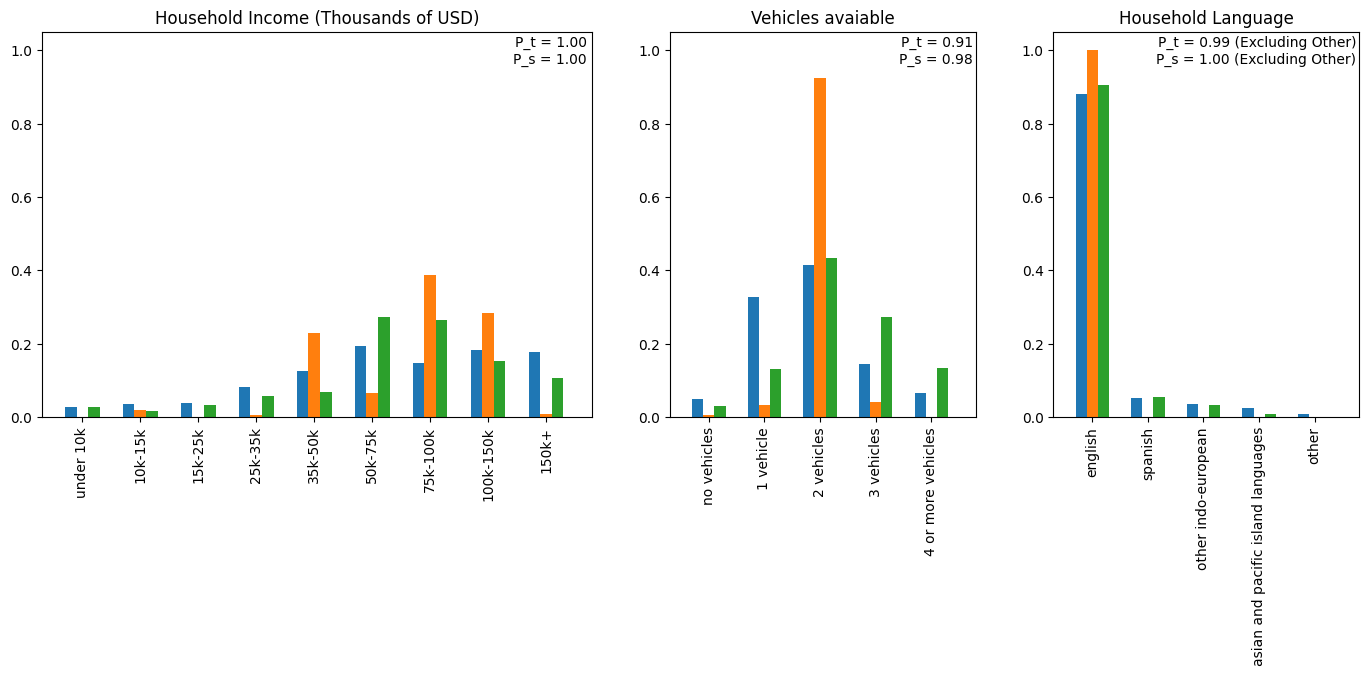

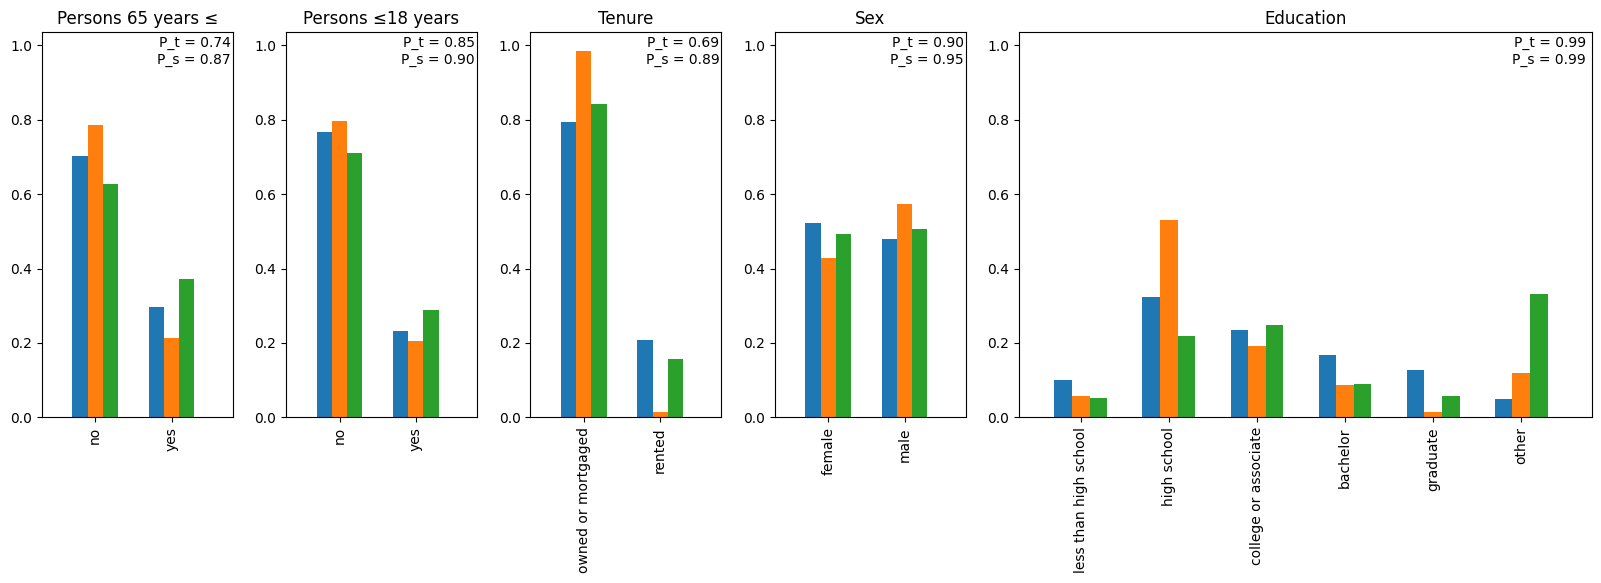

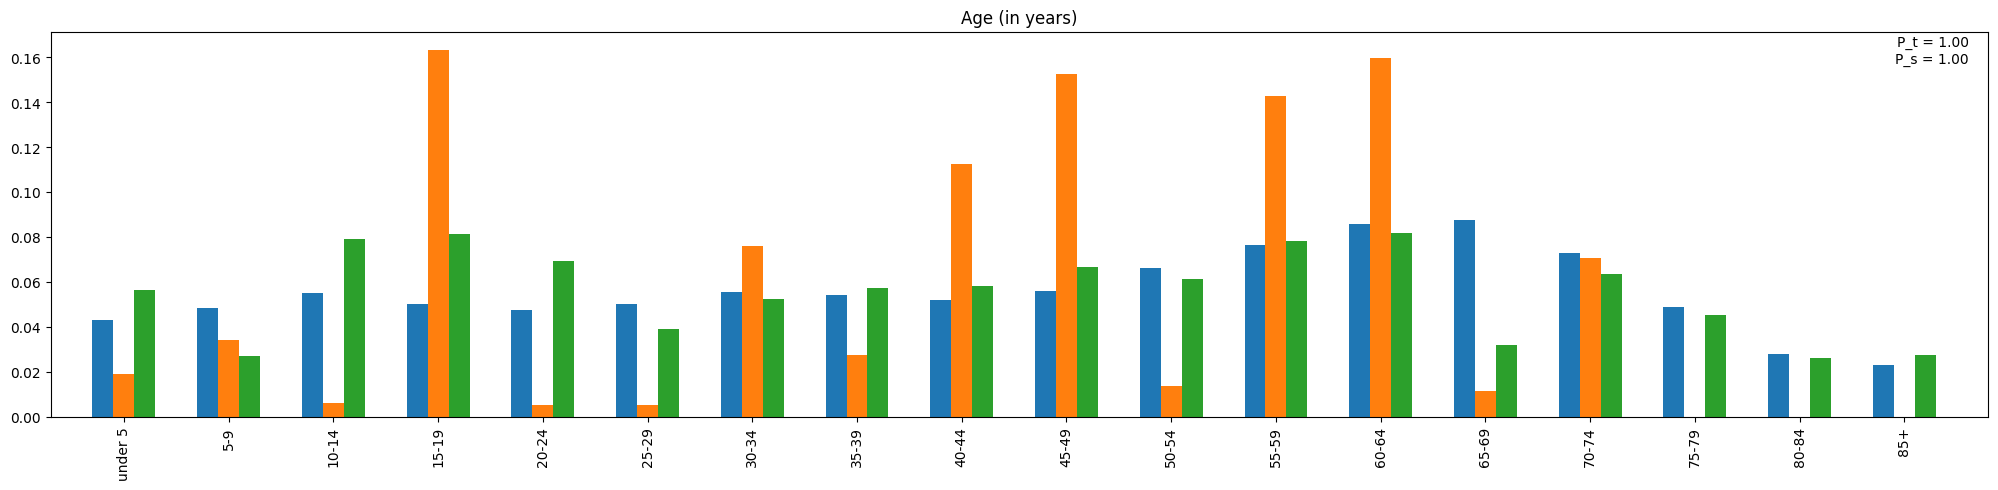

/tmp/ipykernel_8804/2363128495.py:7: RuntimeWarning: divide by zero encountered in log
  return np.sum(arr1*np.log(arr1/arr2))
/tmp/ipykernel_8804/2363128495.py:7: RuntimeWarning: invalid value encountered in multiply
  return np.sum(arr1*np.log(arr1/arr2))


,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.049820,0.108794,0.012224,0.058259,0.057570,0.076221,0.018531,0.132293,0.028900
RMSE Syn. HI.,0.143000,0.253498,0.057054,0.113000,0.085694,0.158563,0.051088,0.157185,0.065250
KL Baseline,0.008682,0.164155,0.011582,0.097999,0.008415,0.012843,0.060321,0.288776,0.001671
KL Syn. HI.,0.120655,NaN,NaN,NaN,0.019123,0.058448,NaN,0.279307,0.008552


In [ ]:
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'plots1')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'plots2')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['AGEP'], legend=False, figsize = (25,5), bbox_to_anchor = (0.65, -0.3), img_name = 'plots3')
create_table(marginals, predicted_marginals, state_marginals, 'table4')

## Recreate plots and table (cheating)

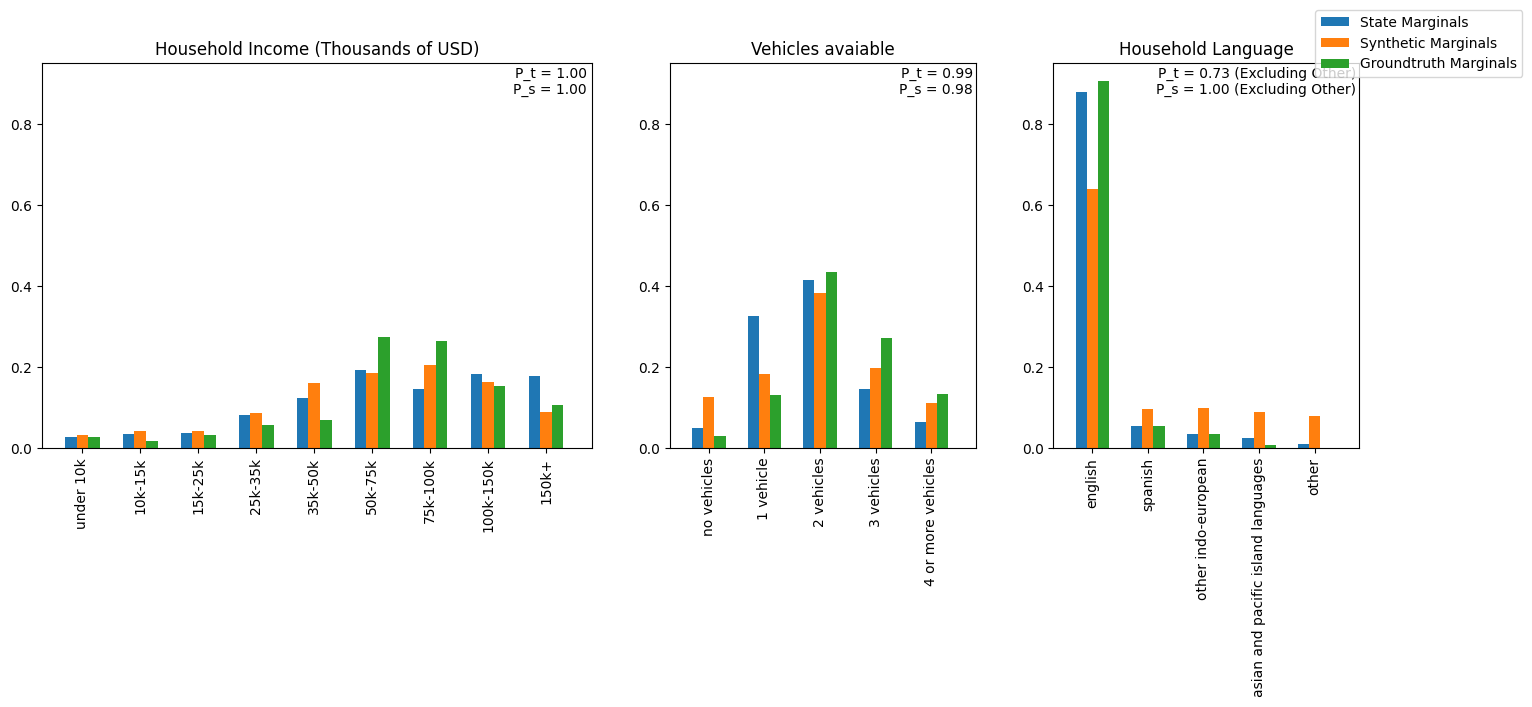

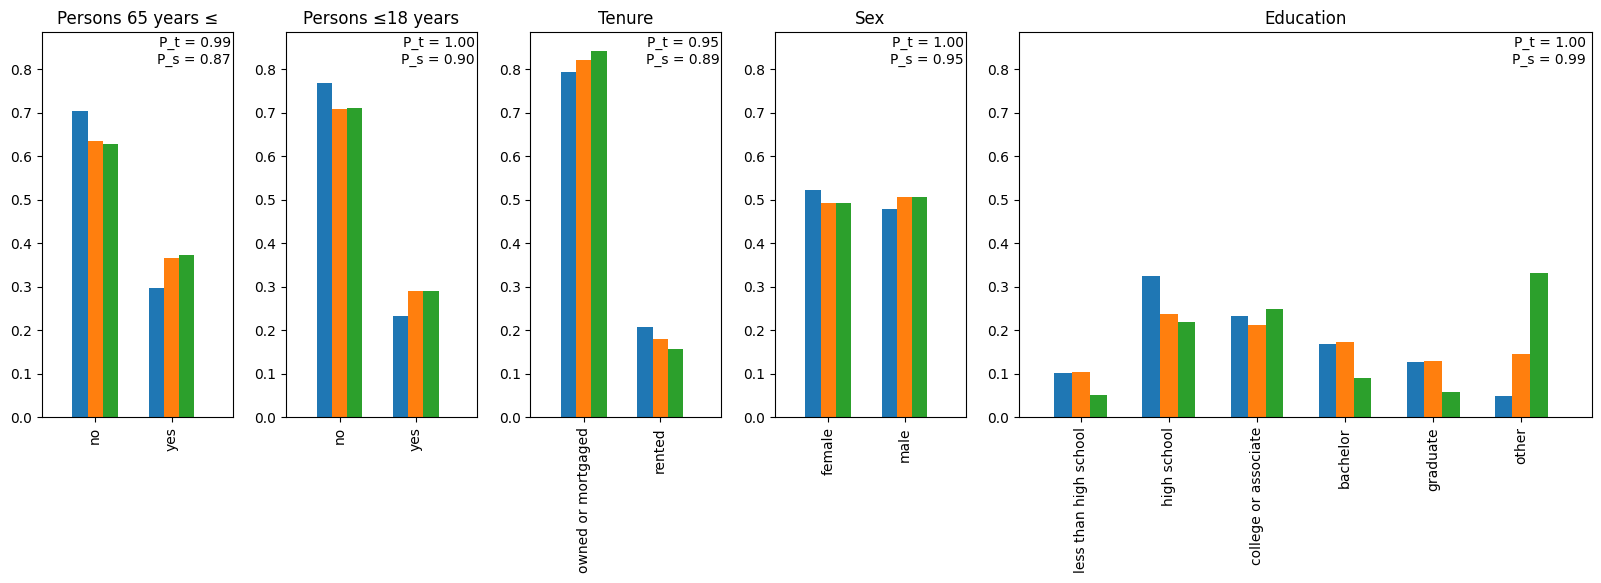

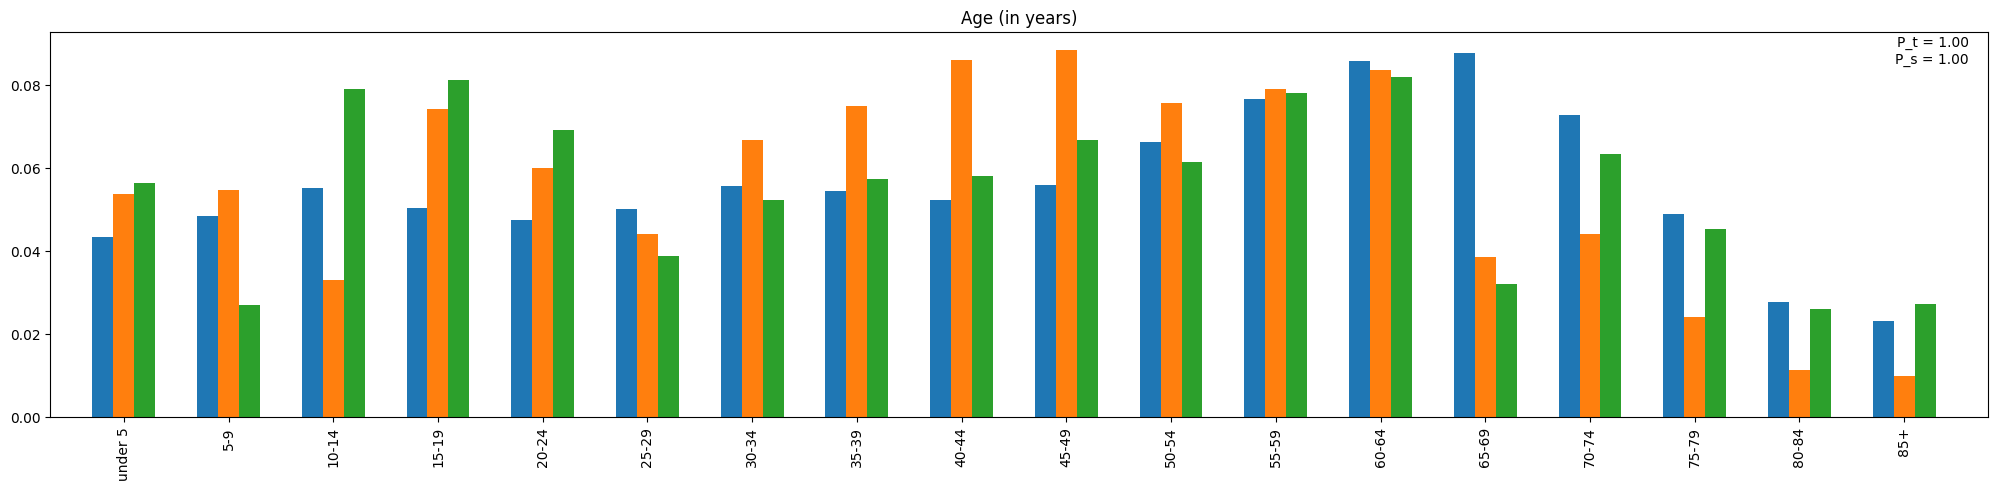

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.049820,0.108794,0.012224,0.058259,0.057570,0.076221,0.018531,0.132293,2.890010e-02
RMSE Syn. HI.,0.022073,0.064143,0.123470,0.049243,0.000723,0.006915,0.018864,0.092323,5.807550e-05
KL Baseline,0.008682,0.164155,0.011582,0.097999,0.008415,0.012843,0.060321,0.288776,1.670789e-03
KL Syn. HI.,0.001775,0.110143,0.253270,0.090142,0.000001,0.000103,0.067055,0.153115,6.746856e-09


In [59]:
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=True, figsize = (17,5), img_name = 'plots1_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'plots2_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['AGEP'], legend=False, figsize = (25,5), bbox_to_anchor = (0.65, -0.3), img_name = 'plots3_cheat')
create_table(marginals, predicted_marginals_cheat, state_marginals, 'table4_cheat')

In [92]:
def split_household_and_individual(data):
    # Households are easy
    household_data = data[:, :27]

    # Individuals:
    # Find number of individuals: Extract one of sets of individual variables and see how many there are
    n_individuals = len([k for k in indices.keys() if k.startswith('SEX')])

    # Initialise individuals table
    individual_tables = []

    for i in range(n_individuals):
        # Extract indices corresponding to individual i
        individual_indices = {k:inds for k,inds in indices.items() if k.endswith(f'_{i+1}')}
        individual_indices_flattened = [ind for inds in individual_indices.values() for ind in inds]

        individual_table = data[:,individual_indices_flattened]

        # Append individual 
        individual_tables.append(individual_table)

    individual_data = np.concatenate(individual_tables, axis=0)

    # Clean: Remove individuals with nans
    nan_columns = [2, 21, 28]
    nan_counts = individual_data[:,nan_columns].sum(axis=1)
    individual_data = individual_data[nan_counts==0]

    return household_data, individual_data

def calculate_bces(microdata, synth_data):
    # Ensure inputs are tensors on CUDA
    if not isinstance(microdata, torch.Tensor):
        microdata = torch.tensor(microdata).float()
    if not isinstance(synth_data, torch.Tensor):
        synth_data = torch.tensor(synth_data).float()

    microdata = microdata.to('cuda')
    synth_data = synth_data.to('cuda')

    # Calculate table of all BCEs
    # predictions: (Nt, D) and labels: (N, D)
    Nt, D = synth_data.shape
    eps = 1e-6  # for numerical stability

    # Clamp predictions to avoid log(0)
    synth_data = torch.clamp(synth_data, min=eps, max= 1 - eps)

    # Compute the logarithms
    log_p = torch.log(synth_data)            # (Nt, D)
    log_1_minus_p = torch.log(1 - synth_data)  # (Nt, D)

    # Compute the pairwise BCE using matrix multiplication:
    # First term: (Nt, D) @ (D, N) gives a (Nt, N) matrix.
    term1 = torch.matmul(log_p, microdata.t())
    # Second term: (Nt, D) @ (D, N) for (1-labels)
    term2 = torch.matmul(log_1_minus_p, (1 - microdata).t())
    
    # Combine the terms and average over D.
    # The minus sign is applied as in the BCE formula.
    bce_all = -(term1 + term2) / D  # shape: (Nt, N)

    min_bce = bce_all.min(dim = 1)[0] # Index 0: extract minima, not indices

    return min_bce.cpu().numpy()

def get_min_bces(microdata: np.ndarray, synth_data: np.ndarray):
    # Split data into household and individual data
    micro_households, micro_individuals = split_household_and_individual(microdata)
    synth_households, synth_individuals = split_household_and_individual(synth_data)

    # Get minimum BCEs for each and return
    household_bces = calculate_bces(micro_households, synth_households)
    individual_bces = calculate_bces(micro_individuals, synth_individuals)

    return household_bces, individual_bces

## Recreate Figure 12
household_bces_finetuned, individual_bces_finetuned = get_min_bces(pums_np, synth_data)


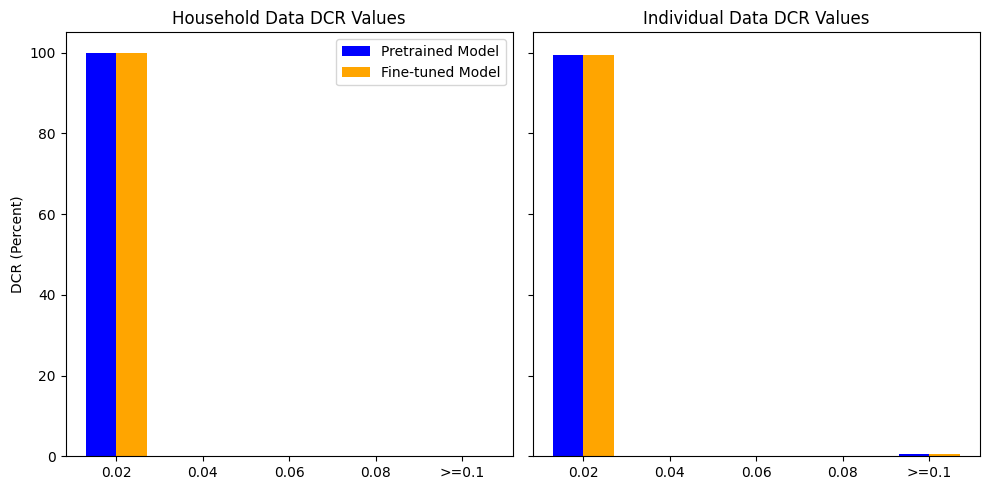

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Example Data
# ==========================
# Replace these with your actual NumPy arrays
household_pretrained = np.random.rand(100)   # DCRs for household data (pretrained)
household_finetuned = np.random.rand(100)    # DCRs for household data (fine-tuned)
individual_pretrained = np.random.rand(100)  # DCRs for individual data (pretrained)
individual_finetuned = np.random.rand(100)   # DCRs for individual data (fine-tuned)

def plot_12(household_pretrained,household_finetuned,individual_pretrained,individual_finetuned):
    # Define Bins and Labels
    bins = [0, 0.02, 0.04, 0.06, 0.08, 1]  
    bin_labels = ['<=0.02', '0.04', '0.06', '0.08', '>=0.1']  # For the x-axis

    # Create Histograms

    hh_pre_hist, _ = np.histogram(household_pretrained, bins=bins)
    hh_ft_hist,  _ = np.histogram(household_finetuned, bins=bins)

    ind_pre_hist, _ = np.histogram(individual_pretrained, bins=bins)
    ind_ft_hist,  _ = np.histogram(individual_finetuned, bins=bins)

    # Convert counts to percentages
    hh_pre_hist = hh_pre_hist / hh_pre_hist.sum() * 100
    hh_ft_hist  = hh_ft_hist  / hh_ft_hist.sum()  * 100
    ind_pre_hist = ind_pre_hist / ind_pre_hist.sum() * 100
    ind_ft_hist  = ind_ft_hist  / ind_ft_hist.sum()  * 100

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # X positions for each bin
    x = np.arange(len(bin_labels))
    width = 0.35

    # Left subplot
    rects1 = ax1.bar(x - width/2, hh_pre_hist, width, label='Pretrained Model', color='blue')
    rects2 = ax1.bar(x + width/2, hh_ft_hist,  width, label='Fine-tuned Model', color='orange')

    ax1.set_title('Household Data DCR Values')
    ax1.set_xticks(x)
    ax1.set_xticklabels(bin_labels)
    ax1.set_ylabel('DCR (Percent)')
    ax1.legend()

    # Right subplot
    rects3 = ax2.bar(x - width/2, ind_pre_hist, width, label='Pretrained Model', color='blue')
    rects4 = ax2.bar(x + width/2, ind_ft_hist,  width, label='Fine-tuned Model', color='orange')

    ax2.set_title('Individual Data DCR Values')
    ax2.set_xticks(x)
    ax2.set_xticklabels(bin_labels)
    # Note: We can optionally add a legend here or rely on ax1's legend


    plt.tight_layout()
    plt.show()

plot_12(household_bces_finetuned, household_bces_finetuned, individual_bces_finetuned, individual_bces_finetuned)
